# Bank Customer Churn Prediction & Retention Analytics System

## 07 — Retention Strategy & Customer Prioritization

### Objective

This notebook converts model-generated churn probabilities into a
business-oriented customer retention prioritization framework.

The analysis combines:

- Churn probability
- Churn risk level
- Customer value proxy
- Customer engagement
- Product relationship
- Geography
- Age

The objective is to identify customers who may require greater retention
attention and assign transparent retention priorities.

### Important Limitation

The dataset does not contain customer revenue, profit, transaction
history, customer lifetime value, or retention campaign outcomes.

Therefore, the project uses a transparent Customer Value Proxy rather
than claiming to calculate actual customer lifetime value.

The resulting retention priorities are analytical recommendations and
should not be interpreted as proven causal intervention strategies.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [94]:
PROJECT_ROOT = Path.cwd().parent

REPORTS_PATH = PROJECT_ROOT / "reports"

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics


In [95]:
prediction_path = (
    REPORTS_PATH /
    "customer_churn_predictions.csv"
)

customer_risk = pd.read_csv(
    prediction_path
)

print("Dataset shape:", customer_risk.shape)

customer_risk.head()

Dataset shape: (10000, 19)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceStatus,ActivityStatus,AgeActivity,CustomerIndex,ChurnProbability,ChurnPrediction,RiskLevel
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Zero Balance,Active,36-45_Active,0,0.345453,0,Moderate
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Positive Balance,Active,36-45_Active,1,0.190369,0,Low
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Positive Balance,Inactive,36-45_Inactive,2,0.907523,1,Very High
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Zero Balance,Inactive,36-45_Inactive,3,0.041149,0,Low
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,Positive Balance,Active,36-45_Active,4,0.066439,0,Low


In [96]:
print("Columns:")
for column in customer_risk.columns:
    print("-", column)

Columns:
- CreditScore
- Geography
- Gender
- Age
- Tenure
- Balance
- NumOfProducts
- HasCrCard
- IsActiveMember
- EstimatedSalary
- Exited
- AgeGroup
- BalanceStatus
- ActivityStatus
- AgeActivity
- CustomerIndex
- ChurnProbability
- ChurnPrediction
- RiskLevel


In [97]:
print(
    "Minimum churn probability:",
    round(customer_risk["ChurnProbability"].min(), 4)
)

print(
    "Maximum churn probability:",
    round(customer_risk["ChurnProbability"].max(), 4)
)

print(
    "Average churn probability:",
    round(customer_risk["ChurnProbability"].mean(), 4)
)

Minimum churn probability: 0.0012
Maximum churn probability: 0.9992
Average churn probability: 0.2038


In [98]:
customer_risk["RiskScore"] = (
    customer_risk["ChurnProbability"] * 100
)

In [99]:
customer_risk[
    [
        "CustomerIndex",
        "ChurnProbability",
        "RiskScore",
        "RiskLevel"
    ]
].head()

,CustomerIndex,ChurnProbability,RiskScore,RiskLevel
0,0,0.345453,34.545302,Moderate
1,1,0.190369,19.036883,Low
2,2,0.907523,90.752300,Very High
3,3,0.041149,4.114937,Low
4,4,0.066439,6.643934,Low


In [100]:
customer_risk["RiskLevel"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[-np.inf, 0.20, 0.35, 0.60, np.inf],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [101]:
risk_summary = (
    customer_risk["RiskLevel"]
    .value_counts(sort=False)
    .to_frame("Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"]
    / len(customer_risk)
    * 100
)

display(
    risk_summary.round(2)
)

,Customers,Percentage
RiskLevel,,
Low,6954,69.54
Moderate,1117,11.17
High,875,8.75
Very High,1054,10.54


In [102]:
print("Balance range:")
print(
    customer_risk["Balance"].min(),
    "to",
    customer_risk["Balance"].max()
)

print("\nNumOfProducts:")
print(
    sorted(
        customer_risk["NumOfProducts"].unique()
    )
)

print("\nActivity:")
print(
    customer_risk["IsActiveMember"]
    .value_counts()
)

Balance range:
0.0 to 250898.09

NumOfProducts:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Activity:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


In [103]:
customer_risk["BalanceValue"] = (
    customer_risk["Balance"]
    .rank(pct=True)
)

In [104]:
customer_risk["ProductValue"] = (
    customer_risk["NumOfProducts"]
    .rank(pct=True)
)

In [105]:
customer_risk["ActivityValue"] = (
    customer_risk["IsActiveMember"]
)

In [106]:
customer_risk["CustomerValueScore"] = (
    0.70 * customer_risk["BalanceValue"]
    +
    0.30 * customer_risk["ProductValue"]
)

customer_risk["CustomerValueScore"] = (
    customer_risk["CustomerValueScore"] * 100
)

In [107]:
customer_risk["CustomerValueScore"] = (
    customer_risk["CustomerValueScore"] * 100
)

In [108]:
customer_risk[
    [
        "Balance",
        "NumOfProducts",
        "IsActiveMember",
        "CustomerValueScore"
    ]
].head(10)

,Balance,NumOfProducts,IsActiveMember,CustomerValueScore
0,0.00,1,1,2029.05
1,83807.86,1,1,3814.75
2,159660.80,3,0,9530.65
3,0.00,2,0,3480.15
4,125510.82,1,1,5882.55
5,113755.78,2,0,6618.25
6,0.00,2,1,3480.15
7,115046.74,4,0,7470.45
8,142051.07,2,1,8220.55
9,134603.88,1,1,6411.05


In [109]:
customer_risk["CustomerValueSegment"] = pd.qcut(
    customer_risk["CustomerValueScore"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ],
    duplicates="drop"
)

In [110]:
value_summary = (
    customer_risk["CustomerValueSegment"]
    .value_counts(sort=False)
    .to_frame("Customers")
)

value_summary["Percentage"] = (
    value_summary["Customers"]
    / len(customer_risk)
    * 100
)

display(
    value_summary.round(2)
)

,Customers,Percentage
CustomerValueSegment,,
Low Value,3676,36.76
Medium Value,2991,29.91
High Value,3333,33.33


In [111]:
def assign_priority(row):

    risk = row["RiskLevel"]
    value = row["CustomerValueSegment"]

    if risk == "Very High" and value == "High Value":
        return "Critical"

    elif risk == "High" and value == "High Value":
        return "Critical"

    elif risk == "Very High" and value == "Medium Value":
        return "High"

    elif risk == "High" and value == "Medium Value":
        return "High"

    elif risk == "Very High" and value == "Low Value":
        return "High"

    elif risk == "High" and value == "Low Value":
        return "Medium"

    elif risk == "Moderate" and value == "High Value":
        return "Medium"

    else:
        return "Monitor"

In [112]:
customer_risk["RetentionPriority"] = (
    customer_risk.apply(
        assign_priority,
        axis=1
    )
)

In [113]:
priority_summary = (
    customer_risk["RetentionPriority"]
    .value_counts()
    .reindex([
        "Monitor",
        "Medium",
        "High",
        "Critical"
    ])
    .fillna(0)
    .astype(int)
    .to_frame("Customers")
)

priority_summary["Percentage"] = (
    priority_summary["Customers"]
    / len(customer_risk)
    * 100
)

display(priority_summary.round(2))

,Customers,Percentage
RetentionPriority,,
Monitor,7616,76.16
Medium,649,6.49
High,1009,10.09
Critical,726,7.26


In [114]:
risk_value_matrix = pd.crosstab(
    customer_risk["RiskLevel"],
    customer_risk["CustomerValueSegment"]
)

risk_value_matrix = risk_value_matrix.reindex(
    index=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    columns=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

display(risk_value_matrix)

CustomerValueSegment,Low Value,Medium Value,High Value
RiskLevel,,,
Low,3006,1796,2152
Moderate,259,403,455
High,194,373,308
Very High,217,419,418


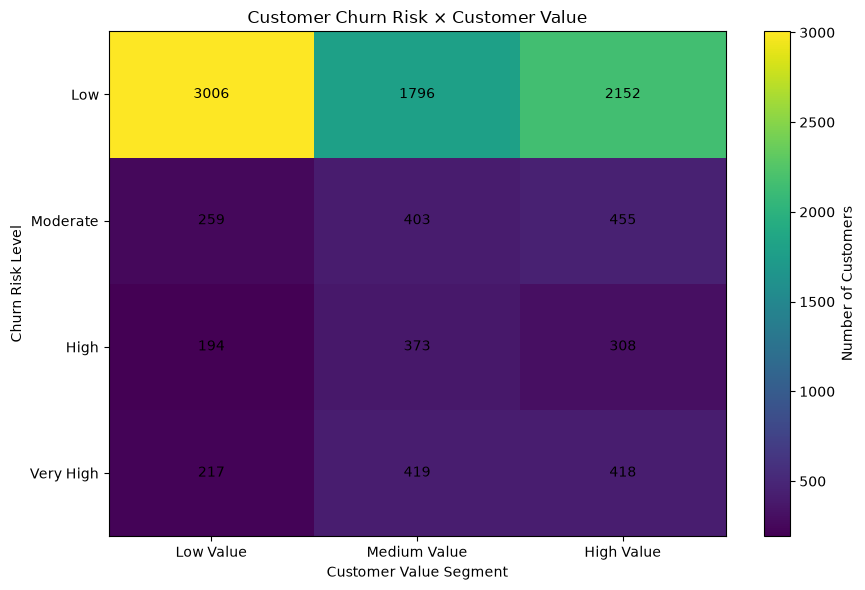

In [115]:
plt.figure(figsize=(9, 6))

plt.imshow(
    risk_value_matrix.values,
    aspect="auto"
)

plt.xticks(
    range(len(risk_value_matrix.columns)),
    risk_value_matrix.columns
)

plt.yticks(
    range(len(risk_value_matrix.index)),
    risk_value_matrix.index
)

plt.xlabel("Customer Value Segment")
plt.ylabel("Churn Risk Level")
plt.title("Customer Churn Risk × Customer Value")

for i in range(
    risk_value_matrix.shape[0]
):
    for j in range(
        risk_value_matrix.shape[1]
    ):
        plt.text(
            j,
            i,
            risk_value_matrix.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(
    label="Number of Customers"
)

plt.tight_layout()
plt.show()

In [116]:
def recommend_action(row):

    risk = row["RiskLevel"]
    value = row["CustomerValueSegment"]
    activity = row["IsActiveMember"]
    products = row["NumOfProducts"]

    if risk in ["Very High", "High"] and value == "High Value":
        return "Priority relationship outreach"

    elif risk in ["Very High", "High"] and activity == 0:
        return "Re-engagement campaign"

    elif risk in ["Very High", "High"] and products == 1:
        return "Product engagement review"

    elif risk in ["Very High", "High"]:
        return "Targeted retention outreach"

    elif risk == "Moderate" and value == "High Value":
        return "Proactive engagement"

    elif risk == "Moderate":
        return "Monitor and engage"

    else:
        return "Standard engagement"

In [117]:
customer_risk["RecommendedAction"] = (
    customer_risk.apply(
        recommend_action,
        axis=1
    )
)

In [118]:
priority_customers = (
    customer_risk[
        customer_risk["RetentionPriority"]
        .isin(["Critical", "High"])
    ]
    .sort_values(
        [
            "RetentionPriority",
            "ChurnProbability"
        ],
        ascending=[True, False]
    )
)

display(
    priority_customers[
        [
            "CustomerIndex",
            "Geography",
            "Age",
            "Balance",
            "NumOfProducts",
            "IsActiveMember",
            "RiskScore",
            "RiskLevel",
            "CustomerValueScore",
            "CustomerValueSegment",
            "RetentionPriority",
            "RecommendedAction"
        ]
    ].head(20)
)

,CustomerIndex,Geography,Age,Balance,NumOfProducts,IsActiveMember,RiskScore,RiskLevel,CustomerValueScore,CustomerValueSegment,RetentionPriority,RecommendedAction
2614,2614,Germany,58,106458.31,4,0,99.921894,Very High,6976.25,High Value,Critical,Priority relationship outreach
70,70,Germany,58,133745.44,4,0,99.896430,Very High,8592.55,High Value,Critical,Priority relationship outreach
8923,8923,Germany,55,118772.71,4,0,99.868506,Very High,7696.55,High Value,Critical,Priority relationship outreach
2154,2154,Germany,65,126306.64,3,0,99.799687,Very High,8107.55,High Value,Critical,Priority relationship outreach
5950,5950,Germany,57,112281.60,3,0,99.798006,Very High,7260.55,High Value,Critical,Priority relationship outreach
9438,9438,Germany,63,120916.52,3,0,99.771450,Very High,7763.85,High Value,Critical,Priority relationship outreach
4013,4013,Germany,57,162082.31,4,0,99.729735,Very High,9630.65,High Value,Critical,Priority relationship outreach
1993,1993,Germany,60,134250.17,3,0,99.729090,Very High,8573.75,High Value,Critical,Priority relationship outreach
1962,1962,Spain,52,143542.36,3,0,99.711930,Very High,9013.35,High Value,Critical,Priority relationship outreach
963,963,Spain,63,96134.11,3,0,99.681900,Very High,6390.45,High Value,Critical,Priority relationship outreach


In [119]:
priority_geo = pd.crosstab(
    customer_risk["Geography"],
    customer_risk["RetentionPriority"]
)

display(priority_geo)

RetentionPriority,Critical,High,Medium,Monitor
Geography,,,,
France,193,356,272,4193
Germany,425,469,241,1374
Spain,108,184,136,2049


In [120]:
priority_activity = pd.crosstab(
    customer_risk["ActivityStatus"],
    customer_risk["RetentionPriority"]
)

display(priority_activity)

RetentionPriority,Critical,High,Medium,Monitor
ActivityStatus,,,,
Active,224,284,314,4329
Inactive,502,725,335,3287


In [121]:
priority_products = pd.crosstab(
    customer_risk["NumOfProducts"],
    customer_risk["RetentionPriority"]
)

display(priority_products)

RetentionPriority,Critical,High,Medium,Monitor
NumOfProducts,,,,
1,419,846,498,3321
2,117,40,150,4283
3,149,104,1,12
4,41,19,0,0


In [122]:
priority_customers_count = customer_risk[
    customer_risk["RetentionPriority"]
    .isin(["Critical", "High"])
].shape[0]

priority_percentage = (
    priority_customers_count
    / len(customer_risk)
    * 100
)

print(
    "Critical + High priority customers:",
    priority_customers_count
)

print(
    "Percentage of customers:",
    round(priority_percentage, 2),
    "%"
)

Critical + High priority customers: 1735
Percentage of customers: 17.35 %


In [123]:
retention_strategy = customer_risk[
    [
        "CustomerIndex",
        "Geography",
        "Gender",
        "Age",
        "AgeGroup",
        "Balance",
        "BalanceStatus",
        "NumOfProducts",
        "IsActiveMember",
        "ActivityStatus",
        "CreditScore",
        "Tenure",
        "EstimatedSalary",
        "ChurnProbability",
        "RiskScore",
        "RiskLevel",
        "CustomerValueScore",
        "CustomerValueSegment",
        "RetentionPriority",
        "RecommendedAction"
    ]
].copy()

In [124]:
print(
    "Retention strategy shape:",
    retention_strategy.shape
)

retention_strategy.head()

Retention strategy shape: (10000, 20)


,CustomerIndex,Geography,Gender,Age,AgeGroup,Balance,BalanceStatus,NumOfProducts,IsActiveMember,ActivityStatus,CreditScore,Tenure,EstimatedSalary,ChurnProbability,RiskScore,RiskLevel,CustomerValueScore,CustomerValueSegment,RetentionPriority,RecommendedAction
0,0,France,Female,42,36-45,0.00,Zero Balance,1,1,Active,619,2,101348.88,0.345453,34.545302,Moderate,2029.05,Low Value,Monitor,Monitor and engage
1,1,Spain,Female,41,36-45,83807.86,Positive Balance,1,1,Active,608,1,112542.58,0.190369,19.036883,Low,3814.75,Medium Value,Monitor,Standard engagement
2,2,France,Female,42,36-45,159660.80,Positive Balance,3,0,Inactive,502,8,113931.57,0.907523,90.752300,Very High,9530.65,High Value,Critical,Priority relationship outreach
3,3,France,Female,39,36-45,0.00,Zero Balance,2,0,Inactive,699,1,93826.63,0.041149,4.114937,Low,3480.15,Low Value,Monitor,Standard engagement
4,4,Spain,Female,43,36-45,125510.82,Positive Balance,1,1,Active,850,2,79084.10,0.066439,6.643934,Low,5882.55,Medium Value,Monitor,Standard engagement


In [125]:
retention_strategy_path = (
    REPORTS_PATH /
    "retention_strategy.csv"
)

retention_strategy.to_csv(
    retention_strategy_path,
    index=False
)

print(
    "Saved:",
    retention_strategy_path
)

Saved: C:\Users\balle\customer-churn-prediction-retention-analytics\reports\retention_strategy.csv


In [126]:
priority_summary.to_csv(
    REPORTS_PATH /
    "retention_priority_summary.csv"
)

risk_value_matrix.to_csv(
    REPORTS_PATH /
    "risk_value_matrix.csv"
)

priority_geo.to_csv(
    REPORTS_PATH /
    "priority_by_geography.csv"
)

priority_activity.to_csv(
    REPORTS_PATH /
    "priority_by_activity.csv"
)

priority_products.to_csv(
    REPORTS_PATH /
    "priority_by_products.csv"
)

print("Day 8 summary reports saved.")

Day 8 summary reports saved.


### Customer Value Proxy

Because the dataset does not contain revenue, profit, transaction
frequency, or customer lifetime value, an actual Customer Lifetime Value
cannot be calculated.

Instead, a transparent Customer Value Proxy is constructed using:

- 70% Balance-based value
- 30% Number-of-products-based value

Customer activity is intentionally excluded from the value proxy because
activity is already an important churn-related variable. This helps keep
the risk and value dimensions conceptually separate.

The resulting value segments are used only for retention prioritization
and should not be interpreted as actual financial customer value.

In [134]:
print("=== DAY 8 FINAL CHECK ===")

print("\nRetention strategy shape:")
print(retention_strategy.shape)

print("\nPriority distribution:")
display(priority_summary.round(2))

print("\nCritical + High customers:")
print(
    customer_risk[
        customer_risk["RetentionPriority"].isin(
            ["Critical", "High"]
        )
    ].shape[0]
)

=== DAY 8 FINAL CHECK ===

Retention strategy shape:
(10000, 20)

Priority distribution:


,Customers,Percentage
RetentionPriority,,
Monitor,7616,76.16
Medium,649,6.49
High,1009,10.09
Critical,726,7.26



Critical + High customers:
1735


In [135]:
files_to_check = [
    "retention_strategy.csv",
    "retention_priority_summary.csv",
    "risk_value_matrix.csv",
    "priority_by_geography.csv",
    "priority_by_activity.csv",
    "priority_by_products.csv"
]

for file in files_to_check:
    print(
        file,
        "→",
        (REPORTS_PATH / file).exists()
    )

retention_strategy.csv → True
retention_priority_summary.csv → True
risk_value_matrix.csv → True
priority_by_geography.csv → True
priority_by_activity.csv → True
priority_by_products.csv → True
